<a href="https://colab.research.google.com/github/shubhangiM2007/MDM_Taska_EE522/blob/main/Task_4_EE522.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree



In [3]:
# step 1 Load dataset
df = pd.read_csv("wireless_signal_quality_dataset.xlsx - Sheet1.csv")

print("First Five Records")
print(df.head())

print("\nDataset Shape :", df.shape)

#defined Features and target
X = df.drop("Quality", axis=1)
y = df["Quality"]

First Five Records
   Signal_Strength_dBm  SNR_dB  Interference_dB  Distance_m  Frequency_GHz  \
0                  -41       6                0         257            5.0   
1                  -86      25               20         134            2.4   
2                  -73      27                0         385            2.4   
3                  -57       5                0         255            5.0   
4                  -87      15               24          61            5.0   

   Channel_Bandwidth_MHz  Noise_Floor_dBm  Connected_Devices  \
0                    160             -100                 24   
1                    160              -96                 41   
2                     20              -72                 13   
3                    160              -86                  9   
4                     20              -79                 32   

   Estimated_Throughput_Mbps Quality  
0                         18    Poor  
1                         55    Poor  
2         

In [4]:
# Step 3 : encode traget lables

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("\nclass Labels:")
print(encoder.classes_)


class Labels:
['Excellent' 'Fair' 'Good' 'Poor']


In [5]:
# step 4 Splite Dataset

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [6]:
#train decision tree

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

dt.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [7]:
# step prediction

y_pred = dt.predict(X_test)


In [8]:
#Step 7 Accuracy

accuracy = accuracy_score(Y_test, y_pred)
print("\nAccuracy : {:.2f}%".format(accuracy * 100))


Accuracy : 92.00%


In [9]:
#step 8 confution matrix

cm = confusion_matrix(Y_test, y_pred)
print("\nConfusion Matrix :")
print(cm)


Confusion Matrix :
[[ 0  0  1  0]
 [ 0  8  1  0]
 [ 0  0  2  0]
 [ 0  0  0 13]]


In [10]:
#step 9  calssification report

print("\nClassification Report")
print(classification_report(
    Y_test,
    y_pred,
    target_names=encoder.classes_
))


Classification Report
              precision    recall  f1-score   support

   Excellent       0.00      0.00      0.00         1
        Fair       1.00      0.89      0.94         9
        Good       0.50      1.00      0.67         2
        Poor       1.00      1.00      1.00        13

    accuracy                           0.92        25
   macro avg       0.62      0.72      0.65        25
weighted avg       0.92      0.92      0.91        25



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
#step 10 Feature Importance

importance = pd.Series(
    dt.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print("\nFeature Importance")
print(importance
)


Feature Importance
Signal_Strength_dBm          0.438873
SNR_dB                       0.365448
Estimated_Throughput_Mbps    0.117036
Interference_dB              0.078643
Distance_m                   0.000000
Frequency_GHz                0.000000
Channel_Bandwidth_MHz        0.000000
Noise_Floor_dBm              0.000000
Connected_Devices            0.000000
dtype: float64


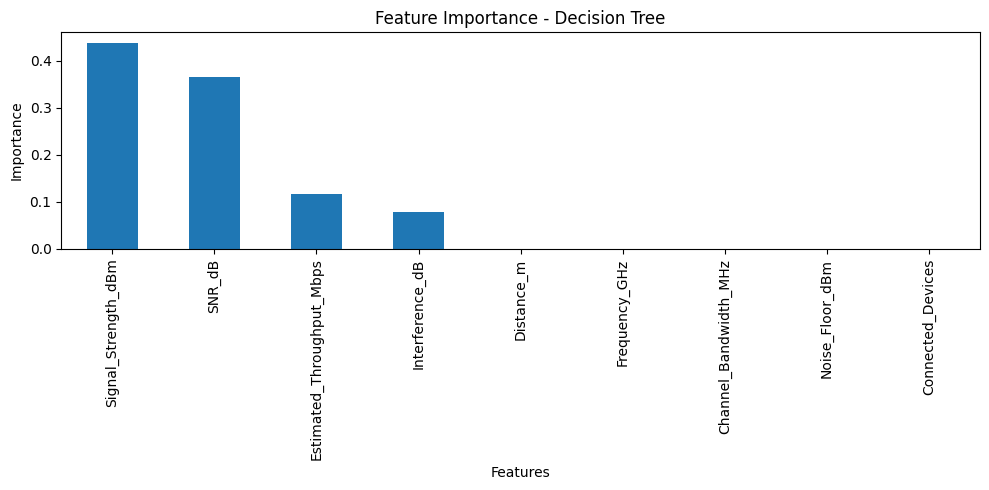

In [12]:
# step 11 plote feature importance
plt.figure(figsize=(10,5))
importance.plot(kind="bar")
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()

[Text(0.3333333333333333, 0.9166666666666666, 'Signal_Strength_dBm <= -79.5\ngini = 0.592\nsamples = 75\nvalue = [1, 28, 8, 38]\nclass = Poor'),
 Text(0.16666666666666666, 0.75, 'gini = 0.0\nsamples = 25\nvalue = [0, 0, 0, 25]\nclass = Poor'),
 Text(0.25, 0.8333333333333333, 'True  '),
 Text(0.5, 0.75, 'SNR_dB <= 12.0\ngini = 0.593\nsamples = 50\nvalue = [1.0, 28.0, 8.0, 13.0]\nclass = Fair'),
 Text(0.41666666666666663, 0.8333333333333333, '  False'),
 Text(0.3333333333333333, 0.5833333333333334, 'gini = 0.0\nsamples = 13\nvalue = [0, 0, 0, 13]\nclass = Poor'),
 Text(0.6666666666666666, 0.5833333333333334, 'Interference_dB <= 15.0\ngini = 0.38\nsamples = 37\nvalue = [1, 28, 8, 0]\nclass = Fair'),
 Text(0.5, 0.4166666666666667, 'Signal_Strength_dBm <= -69.5\ngini = 0.535\nsamples = 20\nvalue = [1, 11, 8, 0]\nclass = Fair'),
 Text(0.3333333333333333, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [0, 7, 0, 0]\nclass = Fair'),
 Text(0.6666666666666666, 0.25, 'Estimated_Throughput_Mbps <= 51.0\ng

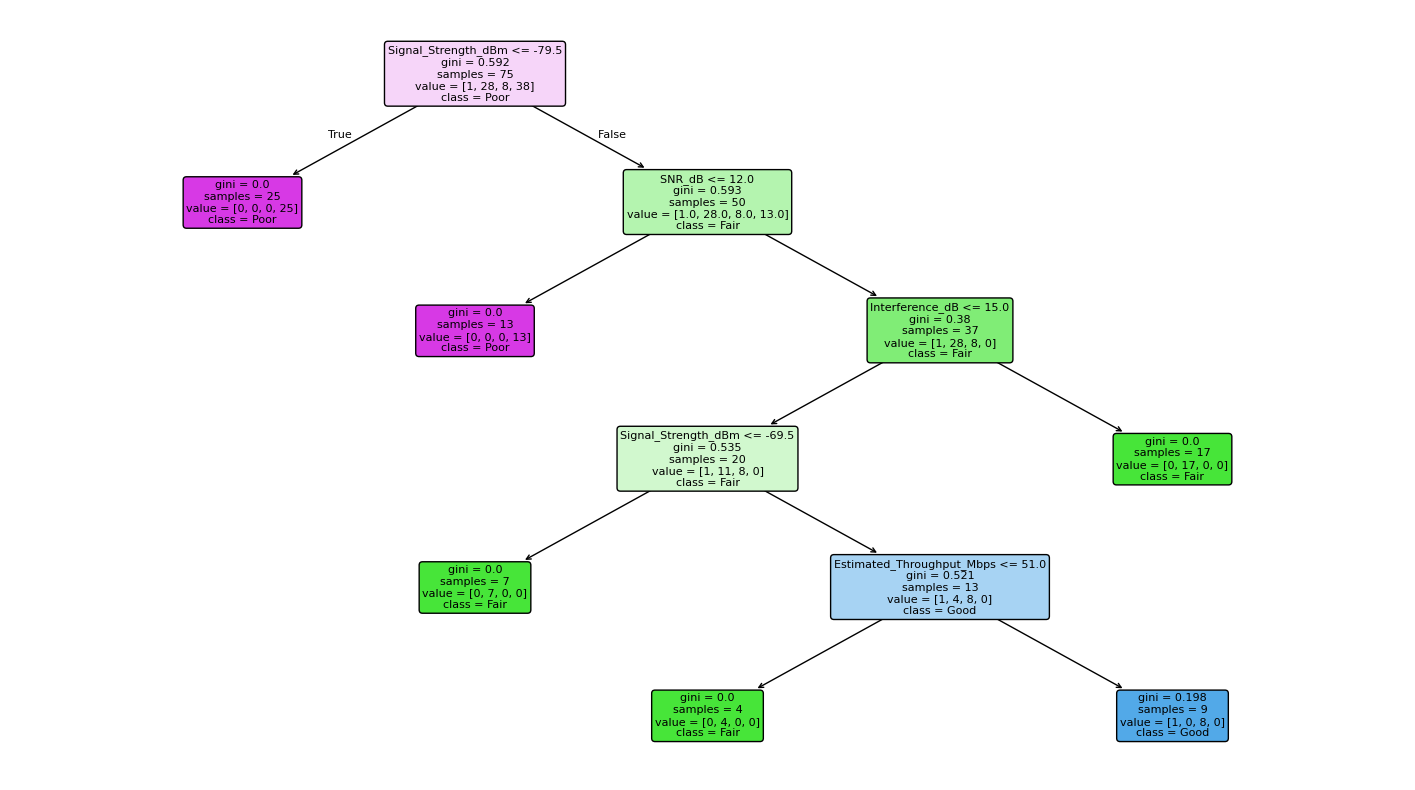

In [13]:
#step 12 Visualise Decision Tree

plt.figure(figsize=(18,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)